## Bureau Balance

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Establish DuckDB connection (in-memory)
con = duckdb.connect()

# File path configuration
PATH = "C:/Users/BeratErcan/Desktop/Data/raw/bureau_balance.csv"

# Load data into a DuckDB View
con.execute(f"""
    CREATE OR REPLACE VIEW bureau_balance AS 
    SELECT * FROM read_csv_auto('{PATH}')
""")

# Dataset Dimensions
print("Row count:", con.execute("SELECT COUNT(*) FROM bureau_balance").fetchone()[0])
print("Column count: 3")

# Preview: First 5 rows
con.execute("SELECT * FROM bureau_balance LIMIT 5").df()

Row count: 27299925
Column count: 3


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [3]:
# DuckDB SUMMARIZE — provides min, max, mean, std, null count, etc.
con.execute("SUMMARIZE bureau_balance").df()

# Distinct value counts
con.execute("""
    SELECT 
        COUNT(DISTINCT SK_ID_BUREAU)   AS unique_bureau_ids,
        COUNT(DISTINCT MONTHS_BALANCE) AS unique_months_count,
        COUNT(DISTINCT STATUS)         AS unique_status_types
    FROM bureau_balance
""").df()

# MONTHS_BALANCE range analysis
con.execute("""
    SELECT 
        MIN(MONTHS_BALANCE) AS oldest_month,
        MAX(MONTHS_BALANCE) AS newest_month,
        MAX(MONTHS_BALANCE) - MIN(MONTHS_BALANCE) AS month_range
    FROM bureau_balance
""").df()

,oldest_month,newest_month,month_range
0,-96,0,96


In [4]:
total = con.execute("SELECT COUNT(*) FROM bureau_balance").fetchone()[0]

null_query = """
    SELECT 
        'SK_ID_BUREAU'   AS column_name,
        COUNT(*) - COUNT(SK_ID_BUREAU)   AS null_count,
        ROUND(100.0 * (COUNT(*) - COUNT(SK_ID_BUREAU)) / COUNT(*), 2) AS null_percentage
    FROM bureau_balance
    UNION ALL
    SELECT 
        'MONTHS_BALANCE',
        COUNT(*) - COUNT(MONTHS_BALANCE),
        ROUND(100.0 * (COUNT(*) - COUNT(MONTHS_BALANCE)) / COUNT(*), 2)
    FROM bureau_balance
    UNION ALL
    SELECT 
        'STATUS',
        COUNT(*) - COUNT(STATUS),
        ROUND(100.0 * (COUNT(*) - COUNT(STATUS)) / COUNT(*), 2)
    FROM bureau_balance
"""

null_df = con.execute(null_query).df()
print(null_df)


      column_name  null_count  null_percentage
0    SK_ID_BUREAU           0              0.0
1  MONTHS_BALANCE           0              0.0
2          STATUS           0              0.0


In [5]:
# Distribution of STATUS values
status_df = con.execute("""
    SELECT 
        STATUS, 
        COUNT(*)                                    AS count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS percentage
    FROM bureau_balance
    GROUP BY STATUS
    ORDER BY count DESC
""").df()
print(status_df)

"""
STATUS meanings:
  0  → No delinquency (on-time payment)
  1  → 1-29 days past due
  2  → 30-59 days past due
  3  → 60-89 days past due
  4  → 90-119 days past due
  5  → 120+ days past due
  C  → Closed (credit completed)
  X  → Unknown status
"""

# Delinquency rate (delays between 1-5)
con.execute("""
    SELECT 
        SUM(CASE WHEN STATUS IN ('1','2','3','4','5') THEN 1 ELSE 0 END) AS delinquency_count,
        ROUND(100.0 * SUM(CASE WHEN STATUS IN ('1','2','3','4','5') THEN 1 ELSE 0 END) 
              / COUNT(*), 2) AS delinquency_rate_pct
    FROM bureau_balance
""").df()

  STATUS     count  percentage
0      C  13646993       49.99
1      0   7499507       27.47
2      X   5810482       21.28
3      1    242347        0.89
4      5     62406        0.23
5      2     23419        0.09
6      3      8924        0.03
7      4      5847        0.02


,delinquency_count,delinquency_rate_pct
0,342943.0,1.26


In [6]:
bureau_group = con.execute("""
    SELECT 
        SK_ID_BUREAU,
        COUNT(*)                    AS record_count,
        MIN(MONTHS_BALANCE)         AS oldest_month,
        MAX(MONTHS_BALANCE)         AS newest_month,
        COUNT(DISTINCT STATUS)      AS unique_status_count,
        SUM(CASE WHEN STATUS IN ('1','2','3','4','5') 
                 THEN 1 ELSE 0 END) AS delinquent_months_count,
        MAX(CASE WHEN STATUS = 'C' THEN 1 ELSE 0 END) AS is_closed
    FROM bureau_balance
    GROUP BY SK_ID_BUREAU
""").df()

# Distribution of record counts
print("Record statistics per credit (bureau ID):")
print(bureau_group['record_count'].describe())

# Credits with the highest number of delinquencies
print("\nTop 10 credits with the highest delinquency frequency:")
print(bureau_group.nlargest(10, 'delinquent_months_count'))

Record statistics per credit (bureau ID):
count    817395.000000
mean         33.398693
std          25.794666
min           1.000000
25%          13.000000
50%          26.000000
75%          48.000000
max          97.000000
Name: record_count, dtype: float64

Top 10 credits with the highest delinquency frequency:
        SK_ID_BUREAU  record_count  oldest_month  newest_month  \
140212       5941006            97           -96             0   
174658       5609996            97           -96             0   
179478       5744002            97           -96             0   
240991       6154878            97           -96             0   
268126       5641256            97           -96             0   
554097       6051262            97           -96             0   
769108       5931486            97           -96             0   
216093       6012757            97           -96             0   
704093       6051010            97           -96             0   
659361       6195829   

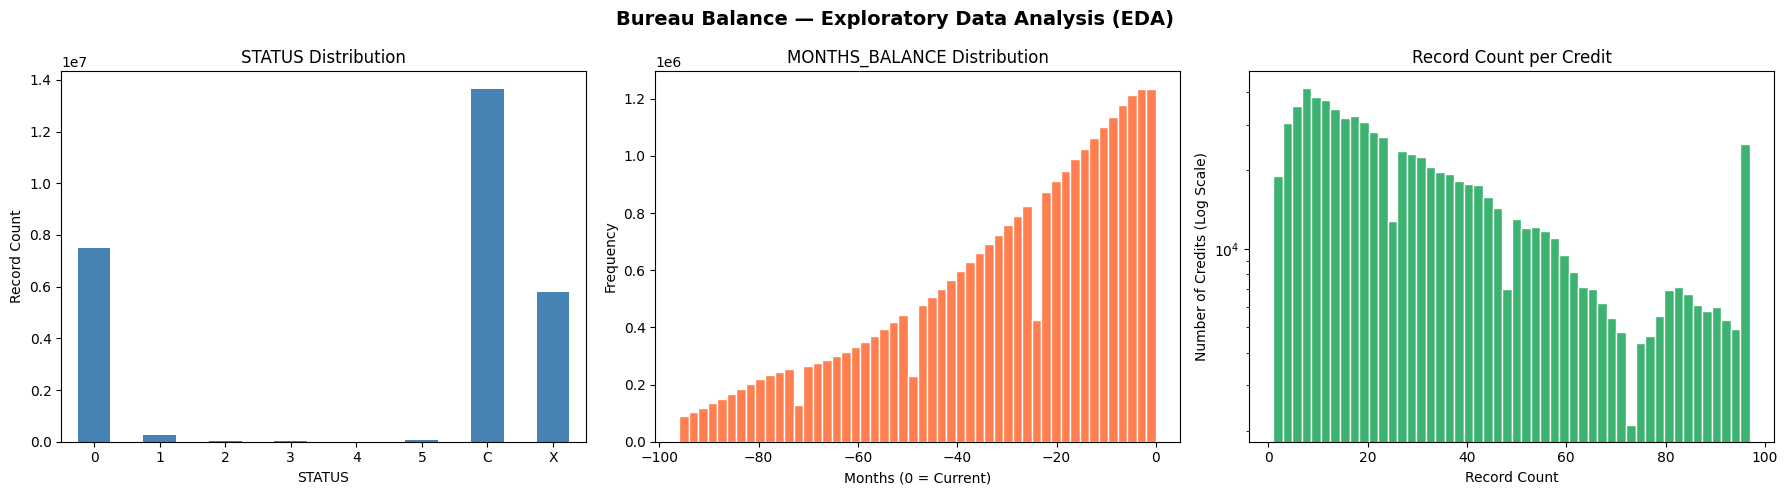

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Bureau Balance — Exploratory Data Analysis (EDA)", fontsize=14, fontweight='bold')

# 1) STATUS bar chart
status_df.sort_values('STATUS').plot(
    kind='bar', x='STATUS', y='count', 
    ax=axes[0], color='steelblue', legend=False
)
axes[0].set_title("STATUS Distribution")
axes[0].set_xlabel("STATUS")
axes[0].set_ylabel("Record Count")
axes[0].tick_params(axis='x', rotation=0)

# 2) MONTHS_BALANCE histogram
months_df = con.execute("SELECT MONTHS_BALANCE FROM bureau_balance").df()
axes[1].hist(months_df['MONTHS_BALANCE'], bins=50, color='coral', edgecolor='white')
axes[1].set_title("MONTHS_BALANCE Distribution")
axes[1].set_xlabel("Months (0 = Current)")
axes[1].set_ylabel("Frequency")

# 3) Record count per credit (log scale)
axes[2].hist(bureau_group['record_count'], bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title("Record Count per Credit")
axes[2].set_xlabel("Record Count")
axes[2].set_ylabel("Number of Credits (Log Scale)")
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

## Bureau

In [8]:
PATH_BUREAU = "C:/Users/BeratErcan/Desktop/Data/raw/bureau.csv"

con.execute(f"""
    CREATE OR REPLACE VIEW bureau AS 
    SELECT * FROM read_csv_auto('{PATH_BUREAU}')
""")

# Dataset Dimensions
row_count = con.execute("SELECT COUNT(*) FROM bureau").fetchone()[0]
col_count = con.execute("SELECT COUNT(*) FROM (DESCRIBE bureau)").fetchone()[0]
print(f"Rows: {row_count:,}  |  Columns: {col_count}")

# Column names and data types
print(con.execute("DESCRIBE bureau").df().to_string())

con.execute("SELECT * FROM bureau LIMIT 5").df()

Rows: 1,716,428  |  Columns: 17
               column_name column_type null   key default extra
0               SK_ID_CURR      BIGINT  YES  None    None  None
1             SK_ID_BUREAU      BIGINT  YES  None    None  None
2            CREDIT_ACTIVE     VARCHAR  YES  None    None  None
3          CREDIT_CURRENCY     VARCHAR  YES  None    None  None
4              DAYS_CREDIT      BIGINT  YES  None    None  None
5       CREDIT_DAY_OVERDUE      BIGINT  YES  None    None  None
6      DAYS_CREDIT_ENDDATE      DOUBLE  YES  None    None  None
7        DAYS_ENDDATE_FACT      DOUBLE  YES  None    None  None
8   AMT_CREDIT_MAX_OVERDUE      DOUBLE  YES  None    None  None
9       CNT_CREDIT_PROLONG      BIGINT  YES  None    None  None
10          AMT_CREDIT_SUM      DOUBLE  YES  None    None  None
11     AMT_CREDIT_SUM_DEBT      DOUBLE  YES  None    None  None
12    AMT_CREDIT_SUM_LIMIT      DOUBLE  YES  None    None  None
13  AMT_CREDIT_SUM_OVERDUE      DOUBLE  YES  None    None  None
14      

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [9]:
# Summary statistics for all columns
con.execute("SUMMARIZE bureau").df()

# Distinct value counts for key columns
con.execute("""
    SELECT 
        COUNT(DISTINCT SK_ID_CURR)      AS unique_customers,
        COUNT(DISTINCT SK_ID_BUREAU)    AS unique_bureau_credits,
        COUNT(DISTINCT CREDIT_ACTIVE)   AS unique_credit_active,
        COUNT(DISTINCT CREDIT_TYPE)     AS unique_credit_type,
        COUNT(DISTINCT CREDIT_CURRENCY) AS unique_currency
    FROM bureau
""").df()

# Number of bureau credits per customer
con.execute("""
    SELECT 
        MIN(credit_count) AS min_credits,
        MAX(credit_count) AS max_credits,
        ROUND(AVG(credit_count), 2) AS avg_credits,
        MEDIAN(credit_count) AS median_credits
    FROM (
        SELECT SK_ID_CURR, COUNT(*) AS credit_count
        FROM bureau
        GROUP BY SK_ID_CURR
    )
""").df()

,min_credits,max_credits,avg_credits,median_credits
0,1,116,5.61,4.0


              column_name  null_count  null_pct
0             AMT_ANNUITY     1226791     71.47
1  AMT_CREDIT_MAX_OVERDUE     1124488     65.51
2       DAYS_ENDDATE_FACT      633653     36.92
3    AMT_CREDIT_SUM_LIMIT      591780     34.48
4     AMT_CREDIT_SUM_DEBT      257669     15.01
5     DAYS_CREDIT_ENDDATE      105553      6.15
6          AMT_CREDIT_SUM          13      0.00
7  AMT_CREDIT_SUM_OVERDUE           0      0.00
8      CNT_CREDIT_PROLONG           0      0.00
9      CREDIT_DAY_OVERDUE           0      0.00


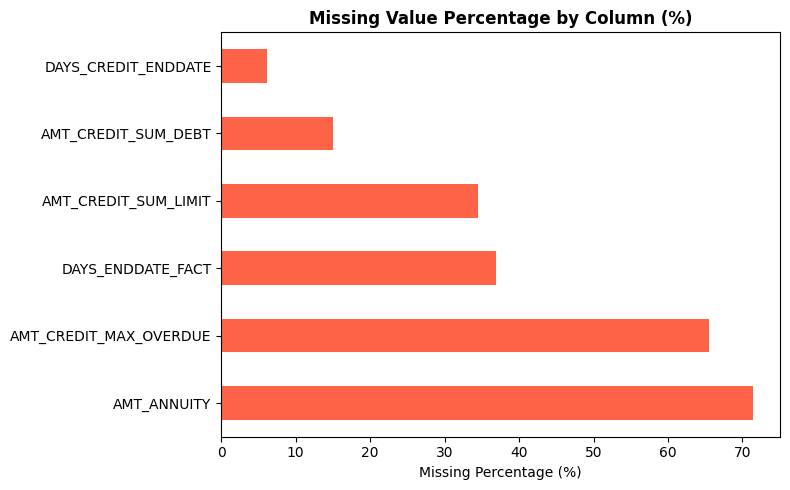

In [10]:
null_query = """
    SELECT column_name, null_count,
           ROUND(100.0 * null_count / total, 2) AS null_pct
    FROM (
        SELECT 'DAYS_CREDIT_ENDDATE'   AS column_name, COUNT(*) - COUNT(DAYS_CREDIT_ENDDATE)   AS null_count, COUNT(*) AS total FROM bureau UNION ALL
        SELECT 'DAYS_ENDDATE_FACT',                    COUNT(*) - COUNT(DAYS_ENDDATE_FACT),                    COUNT(*) FROM bureau UNION ALL
        SELECT 'AMT_CREDIT_MAX_OVERDUE',               COUNT(*) - COUNT(AMT_CREDIT_MAX_OVERDUE),               COUNT(*) FROM bureau UNION ALL
        SELECT 'AMT_CREDIT_SUM',                       COUNT(*) - COUNT(AMT_CREDIT_SUM),                       COUNT(*) FROM bureau UNION ALL
        SELECT 'AMT_CREDIT_SUM_DEBT',                  COUNT(*) - COUNT(AMT_CREDIT_SUM_DEBT),                  COUNT(*) FROM bureau UNION ALL
        SELECT 'AMT_CREDIT_SUM_LIMIT',                 COUNT(*) - COUNT(AMT_CREDIT_SUM_LIMIT),                 COUNT(*) FROM bureau UNION ALL
        SELECT 'AMT_CREDIT_SUM_OVERDUE',               COUNT(*) - COUNT(AMT_CREDIT_SUM_OVERDUE),               COUNT(*) FROM bureau UNION ALL
        SELECT 'AMT_ANNUITY',                          COUNT(*) - COUNT(AMT_ANNUITY),                          COUNT(*) FROM bureau UNION ALL
        SELECT 'CNT_CREDIT_PROLONG',                   COUNT(*) - COUNT(CNT_CREDIT_PROLONG),                   COUNT(*) FROM bureau UNION ALL
        SELECT 'CREDIT_DAY_OVERDUE',                   COUNT(*) - COUNT(CREDIT_DAY_OVERDUE),                   COUNT(*) FROM bureau
    )
    ORDER BY null_pct DESC
"""
null_df = con.execute(null_query).df()
print(null_df)

# Visualize missing values
null_df[null_df['null_pct'] > 0].plot(
    kind='barh', x='column_name', y='null_pct',
    figsize=(8, 5), color='tomato', legend=False
)
plt.title("Missing Value Percentage by Column (%)", fontweight='bold')
plt.xlabel("Missing Percentage (%)")
plt.ylabel("") # Y-ekseni etiketini boş bıraktım, çünkü kolon isimleri zaten kendini açıklıyor.
plt.tight_layout()
plt.show()

Missing Value Analysis (Domain Interpretation)

    71% — AMT_ANNUITY (Completely Normal): Annuity (installment payments) only applies to specific loan types, such as consumer loans. Products like credit cards or revolving loans do not have an annuity concept, so it is expected to be left blank (null).

    65% — AMT_CREDIT_MAX_OVERDUE (Generally Normal): This field represents the maximum overdue amount in the history of that specific credit. For accounts that have never experienced a delay, this field is naturally left blank. However, 65% is relatively high, indicating potential data quality or reporting inconsistencies as well.

    37% — DAYS_ENDDATE_FACT (Completely Normal): This field represents the actual end date and is only populated for closed credits. For currently active credits, there is no actual end date yet, so it remains null. We expect this to be filled primarily when CREDIT_ACTIVE = 'Closed'.

    34% — AMT_CREDIT_SUM_LIMIT (Completely Normal): This field is only meaningful for revolving credits (e.g., credit cards). Standard products like cash loans or mortgages do not have a "credit limit" concept, causing this field to remain null.

    15% — AMT_CREDIT_SUM_DEBT (Partially Normal): For closed credits, the remaining debt is zero, which institutions might sometimes record as a null value rather than '0'. However, for active credits, this field should ideally be populated, suggesting a minor data reporting issue from the credit bureaus.

    6% — DAYS_CREDIT_ENDDATE (Partially Normal): The planned end date might be unknown or undefined for active loans with flexible or indefinite terms (like certain revolving credits). A 6% missing rate is quite low and can be easily handled during the imputation strategy.

    0% — AMT_CREDIT_SUM, AMT_CREDIT_SUM_OVERDUE, CREDIT_DAY_OVERDUE, CNT_CREDIT_PROLONG (Completely Normal): These are mandatory, fundamental financial fields for any credit record. Finding zero missing values here indicates strong core data integrity.

In [11]:
# Distribution of CREDIT_ACTIVE
print("--- CREDIT_ACTIVE Distribution ---")
print(con.execute("""
    SELECT CREDIT_ACTIVE, COUNT(*) AS count, 
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct
    FROM bureau GROUP BY CREDIT_ACTIVE ORDER BY count DESC
""").df())

# Distribution of CREDIT_TYPE
print("\n--- CREDIT_TYPE (Top 10) ---")
print(con.execute("""
    SELECT CREDIT_TYPE, COUNT(*) AS count, 
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct
    FROM bureau GROUP BY CREDIT_TYPE ORDER BY count DESC LIMIT 10
""").df())

# Distribution of CREDIT_CURRENCY
print("\n--- CREDIT_CURRENCY Distribution ---")
print(con.execute("""
    SELECT CREDIT_CURRENCY, COUNT(*) AS count, 
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct
    FROM bureau GROUP BY CREDIT_CURRENCY ORDER BY count DESC
""").df())

--- CREDIT_ACTIVE Distribution ---
  CREDIT_ACTIVE    count    pct
0        Closed  1079273  62.88
1        Active   630607  36.74
2          Sold     6527   0.38
3      Bad debt       21   0.00

--- CREDIT_TYPE (Top 10) ---
                              CREDIT_TYPE    count    pct
0                         Consumer credit  1251615  72.92
1                             Credit card   402195  23.43
2                                Car loan    27690   1.61
3                                Mortgage    18391   1.07
4                               Microloan    12413   0.72
5           Loan for business development     1975   0.12
6                    Another type of loan     1017   0.06
7                    Unknown type of loan      555   0.03
8  Loan for working capital replenishment      469   0.03
9               Cash loan (non-earmarked)       56   0.00

--- CREDIT_CURRENCY Distribution ---
  CREDIT_CURRENCY    count    pct
0      currency 1  1715020  99.92
1      currency 2     1224   0.

In [12]:
# DAYS_CREDIT — How many days before current application did client apply for Credit Bureau credit
print("--- DAYS_CREDIT ---")
print(con.execute("""
    SELECT 
        MIN(DAYS_CREDIT)             AS min_days,
        MAX(DAYS_CREDIT)             AS max_days,
        ROUND(AVG(DAYS_CREDIT), 1)   AS avg_days,
        MEDIAN(DAYS_CREDIT)          AS median_days
    FROM bureau
""").df())

# CREDIT_DAY_OVERDUE — Number of days past due on CB credit at the time of application
print("\n--- CREDIT_DAY_OVERDUE (Past due records analysis) ---")
print(con.execute("""
    SELECT 
        COUNT(*)                                                AS total_count,
        SUM(CASE WHEN CREDIT_DAY_OVERDUE > 0 THEN 1 ELSE 0 END) AS past_due_count,
        ROUND(100.0 * SUM(CASE WHEN CREDIT_DAY_OVERDUE > 0 THEN 1 ELSE 0 END) 
              / COUNT(*), 2)                                    AS past_due_pct,
        MAX(CREDIT_DAY_OVERDUE)                                 AS max_past_due_days
    FROM bureau
""").df())

# AMT_CREDIT_SUM — Current credit amount for the Credit Bureau credit
print("\n--- AMT_CREDIT_SUM ---")
print(con.execute("""
    SELECT 
        ROUND(MIN(AMT_CREDIT_SUM), 0)    AS min_amount,
        ROUND(MAX(AMT_CREDIT_SUM), 0)    AS max_amount,
        ROUND(AVG(AMT_CREDIT_SUM), 0)    AS avg_amount,
        ROUND(MEDIAN(AMT_CREDIT_SUM), 0) AS median_amount
    FROM bureau WHERE AMT_CREDIT_SUM IS NOT NULL
""").df())

--- DAYS_CREDIT ---
   min_days  max_days  avg_days  median_days
0     -2922         0   -1142.1       -987.0

--- CREDIT_DAY_OVERDUE (Past due records analysis) ---
   total_count  past_due_count  past_due_pct  max_past_due_days
0      1716428          4217.0          0.25               2792

--- AMT_CREDIT_SUM ---
   min_amount   max_amount  avg_amount  median_amount
0         0.0  585000000.0    354995.0       125519.0


Credit History (DAYS_CREDIT): The oldest credit application in the dataset dates back exactly 8 years (-2,922 days). The median of customers' past credit application times points to approximately 2.5 years ago (-987 days).

Current Overdue Status (CREDIT_DAY_OVERDUE): As expected, the proportion of records with an active overdue at the time of application is only 0.25% — remarkably low. However, looking at the maximum value, there is an extreme case of 2,792 days (approximately 7.5 years) of overdue. Such extreme outliers are precisely the kind of "defaulted credit" signals that a predictive model would aim to capture.

Credit Amount (AMT_CREDIT_SUM): A classic right-skewed financial distribution. While most customers borrow around 125,000 (median), an extreme outlier of 585 million pulls the mean all the way up to 354,000 — a textbook example of how outliers distort the average in financial data.

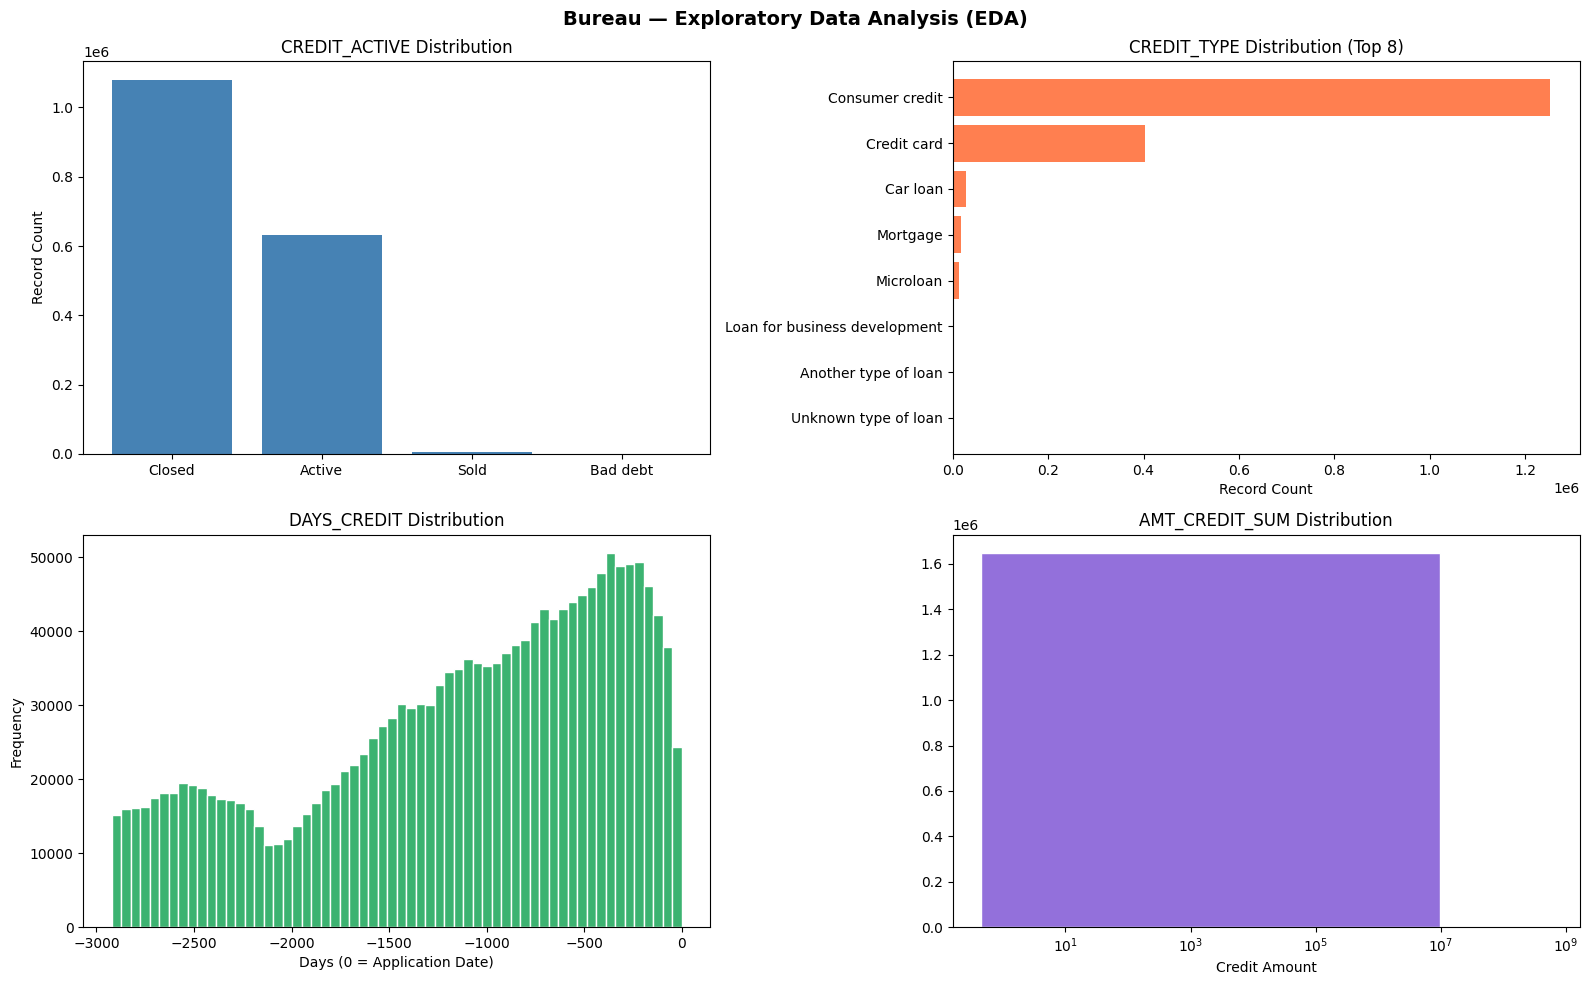

In [13]:
%matplotlib inline
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Bureau — Exploratory Data Analysis (EDA)", fontsize=14, fontweight='bold')

# 1) CREDIT_ACTIVE bar chart
active_df = con.execute("""
    SELECT CREDIT_ACTIVE, COUNT(*) AS count FROM bureau
    GROUP BY CREDIT_ACTIVE ORDER BY count DESC
""").df()
axes[0,0].bar(active_df['CREDIT_ACTIVE'], active_df['count'], color='steelblue')
axes[0,0].set_title("CREDIT_ACTIVE Distribution")
axes[0,0].set_ylabel("Record Count")

# 2) CREDIT_TYPE horizontal bar chart (Top 8)
type_df = con.execute("""
    SELECT CREDIT_TYPE, COUNT(*) AS count FROM bureau
    GROUP BY CREDIT_TYPE ORDER BY count DESC LIMIT 8
""").df()
axes[0,1].barh(type_df['CREDIT_TYPE'], type_df['count'], color='coral')
axes[0,1].set_title("CREDIT_TYPE Distribution (Top 8)")
axes[0,1].set_xlabel("Record Count")
axes[0,1].invert_yaxis()

# 3) DAYS_CREDIT histogram
days_df = con.execute("SELECT DAYS_CREDIT FROM bureau").df()
axes[1,0].hist(days_df['DAYS_CREDIT'], bins=60, color='mediumseagreen', edgecolor='white')
axes[1,0].set_title("DAYS_CREDIT Distribution")
axes[1,0].set_xlabel("Days (0 = Application Date)")
axes[1,0].set_ylabel("Frequency")

# 4) AMT_CREDIT_SUM histogram (log scale)
amt_df = con.execute("""
    SELECT AMT_CREDIT_SUM FROM bureau
    WHERE AMT_CREDIT_SUM IS NOT NULL AND AMT_CREDIT_SUM > 0
""").df()
axes[1,1].hist(amt_df['AMT_CREDIT_SUM'], bins=60, color='mediumpurple', edgecolor='white')
axes[1,1].set_title("AMT_CREDIT_SUM Distribution")
axes[1,1].set_xlabel("Credit Amount")
axes[1,1].set_xscale('log')

plt.tight_layout()
plt.show()


CREDIT_ACTIVE: The majority of historical records are 'Closed', followed by a significant portion of 'Active' loans. Although 'Sold' and 'Bad debt' categories appear visually negligible, creating a binary flag for these rare statuses is highly recommended, as they are exceptionally strong indicators of financial distress.

CREDIT_TYPE: The portfolio is heavily dominated by 'Consumer credit' and 'Credit cards'. To prevent high dimensionality during One-Hot Encoding, it is a best practice to group the remaining low-frequency categories (e.g., Car loan, Microloan) into a single 'Other' bucket.

DAYS_CREDIT: The histogram reveals a left-skewed distribution where credit application frequency increases as we approach the current application date (Day 0). This suggests that recent credit-seeking behavior is common and creating recency-based features (e.g., 'credits_in_last_1_year') will be highly predictive.

AMT_CREDIT_SUM: Even on a logarithmic scale, the data appears compressed. This visually confirms the presence of extreme outliers (such as the 585M maximum value observed previously). Winsorization (capping) will be strictly necessary if these features are fed into linear models like Logistic Regression, though tree-based algorithms can handle them natively

# Join bureau_balance to bureau on SK_ID_BUREAU

In [14]:
# Step 1 — Aggregate bureau_balance to SK_ID_BUREAU level first
con.execute("""
    CREATE VIEW bureau_balance_agg AS
    SELECT
        SK_ID_BUREAU,
        COUNT(*)                                                           as bb_total_months,
        SUM(CASE WHEN STATUS = 'C' THEN 1 ELSE 0 END)                    as bb_closed_months,
        SUM(CASE WHEN STATUS = 'X' THEN 1 ELSE 0 END)                    as bb_unknown_months,
        SUM(CASE WHEN STATUS IN ('1','2','3','4','5') 
            THEN 1 ELSE 0 END)                                            as bb_dpd_months,
        MAX(CAST(CASE WHEN STATUS IN ('1','2','3','4','5') 
            THEN STATUS ELSE '0' END AS INTEGER))                         as bb_max_dpd_status,
        ROUND(SUM(CASE WHEN STATUS IN ('1','2','3','4','5') 
            THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 4)                     as bb_dpd_rate
    FROM bureau_balance
    GROUP BY SK_ID_BUREAU
""")

# Step 2 — Join aggregated bureau_balance to bureau, then aggregate to SK_ID_CURR
bureau_agg = con.execute("""
    SELECT
        b.SK_ID_CURR,
        
        -- Bureau volume
        COUNT(DISTINCT b.SK_ID_BUREAU)                                    as bur_loan_count,
        
        -- Credit status
        SUM(CASE WHEN b.CREDIT_ACTIVE = 'Active' 
            THEN 1 ELSE 0 END)                                            as bur_active_count,
        SUM(CASE WHEN b.CREDIT_ACTIVE = 'Closed' 
            THEN 1 ELSE 0 END)                                            as bur_closed_count,
        SUM(CASE WHEN b.CREDIT_ACTIVE = 'Bad debt' 
            THEN 1 ELSE 0 END)                                            as bur_bad_debt_count,
        
        -- Credit amounts
        AVG(b.AMT_CREDIT_SUM)                                             as bur_avg_credit,
        SUM(b.AMT_CREDIT_SUM)                                             as bur_total_credit,
        AVG(b.AMT_CREDIT_SUM_DEBT)                                        as bur_avg_debt,
        SUM(b.AMT_CREDIT_SUM_DEBT)                                        as bur_total_debt,
        AVG(b.AMT_CREDIT_SUM_OVERDUE)                                     as bur_avg_overdue,
        
        -- Overdue flag
        SUM(CASE WHEN b.CREDIT_DAY_OVERDUE > 0 
            THEN 1 ELSE 0 END)                                            as bur_overdue_count,
        MAX(b.CREDIT_DAY_OVERDUE)                                         as bur_max_overdue_days,
        
        -- Recency
        MAX(b.DAYS_CREDIT)                                                as bur_most_recent_credit,
        AVG(b.DAYS_CREDIT)                                                as bur_avg_days_credit,
        
        -- Bureau balance features (from aggregated child table)
        AVG(bb.bb_total_months)                                           as bur_avg_months_history,
        SUM(bb.bb_dpd_months)                                             as bur_total_dpd_months,
        AVG(bb.bb_dpd_rate)                                               as bur_avg_dpd_rate,
        MAX(bb.bb_max_dpd_status)                                         as bur_max_dpd_status

    FROM bureau b
    LEFT JOIN bureau_balance_agg bb ON b.SK_ID_BUREAU = bb.SK_ID_BUREAU
    GROUP BY b.SK_ID_CURR
""").df()

print(bureau_agg.shape)  # Should be around 305,811 rows
bureau_agg.head()
bureau_agg.to_csv('C:/Users/BeratErcan/Home-Credit-Default-Risk/data/processed/bureau_agg.csv', index=False)

(305811, 18)


In [15]:
print(bureau_agg.shape)
bureau_agg.isnull().sum()

(305811, 18)


SK_ID_CURR                     0
bur_loan_count                 0
bur_active_count               0
bur_closed_count               0
bur_bad_debt_count             0
bur_avg_credit                 2
bur_total_credit               2
bur_avg_debt                8372
bur_total_debt              8372
bur_avg_overdue                0
bur_overdue_count              0
bur_max_overdue_days           0
bur_most_recent_credit         0
bur_avg_days_credit            0
bur_avg_months_history    171269
bur_total_dpd_months      171269
bur_avg_dpd_rate          171269
bur_max_dpd_status        171269
dtype: int64

In [18]:
bureau_agg['bur_avg_debt'] = bureau_agg['bur_avg_debt'].fillna(0) # People may have 0 debt
bureau_agg['bur_total_debt'] = bureau_agg['bur_total_debt'].fillna(0) # People may have 0 debt

In [19]:
bb_cols = ['bur_avg_months_history', 'bur_total_dpd_months', 'bur_avg_dpd_rate', 'bur_max_dpd_status'] # If they have 0 dept this makes sense too
bureau_agg[bb_cols] = bureau_agg[bb_cols].fillna(0)

In [22]:
print(bureau_agg.isnull().sum())

SK_ID_CURR                0
bur_loan_count            0
bur_active_count          0
bur_closed_count          0
bur_bad_debt_count        0
bur_avg_credit            2
bur_total_credit          2
bur_avg_debt              0
bur_total_debt            0
bur_avg_overdue           0
bur_overdue_count         0
bur_max_overdue_days      0
bur_most_recent_credit    0
bur_avg_days_credit       0
bur_avg_months_history    0
bur_total_dpd_months      0
bur_avg_dpd_rate          0
bur_max_dpd_status        0
dtype: int64


In [23]:
# Debt utilization — how much of total credit is currently debt
bureau_agg['bur_debt_to_credit_ratio'] = (
    bureau_agg['bur_total_debt'] / bureau_agg['bur_total_credit'].replace(0, None)
)

# Active loan ratio — what proportion of loans are still open
bureau_agg['bur_active_ratio'] = (
    bureau_agg['bur_active_count'] / bureau_agg['bur_loan_count']
)

# Bad debt flag — binary, any bad debt at all
bureau_agg['bur_has_bad_debt'] = (
    bureau_agg['bur_bad_debt_count'] > 0
).astype(int)

# Overdue ratio — what proportion of loans had overdue payments
bureau_agg['bur_overdue_ratio'] = (
    bureau_agg['bur_overdue_count'] / bureau_agg['bur_loan_count']
)

# Handle infinities from division
bureau_agg = bureau_agg.replace([float('inf'), float('-inf')], None)

print(bureau_agg.shape)
bureau_agg.isnull().sum()

(305811, 22)


SK_ID_CURR                     0
bur_loan_count                 0
bur_active_count               0
bur_closed_count               0
bur_bad_debt_count             0
bur_avg_credit                 2
bur_total_credit               2
bur_avg_debt                   0
bur_total_debt                 0
bur_avg_overdue                0
bur_overdue_count              0
bur_max_overdue_days           0
bur_most_recent_credit         0
bur_avg_days_credit            0
bur_avg_months_history         0
bur_total_dpd_months           0
bur_avg_dpd_rate               0
bur_max_dpd_status             0
bur_debt_to_credit_ratio    1276
bur_active_ratio               0
bur_has_bad_debt               0
bur_overdue_ratio              0
dtype: int64

In [24]:
bureau_agg["bur_debt_to_credit_ratio"] = bureau_agg["bur_debt_to_credit_ratio"].fillna(0)

In [26]:
print(bureau_agg.shape)
bureau_agg.isnull().sum()

(305811, 22)


SK_ID_CURR                  0
bur_loan_count              0
bur_active_count            0
bur_closed_count            0
bur_bad_debt_count          0
bur_avg_credit              2
bur_total_credit            2
bur_avg_debt                0
bur_total_debt              0
bur_avg_overdue             0
bur_overdue_count           0
bur_max_overdue_days        0
bur_most_recent_credit      0
bur_avg_days_credit         0
bur_avg_months_history      0
bur_total_dpd_months        0
bur_avg_dpd_rate            0
bur_max_dpd_status          0
bur_debt_to_credit_ratio    0
bur_active_ratio            0
bur_has_bad_debt            0
bur_overdue_ratio           0
dtype: int64

In [30]:
bureau_agg.to_csv('C:/Users/BeratErcan/Home-Credit-Default-Risk/data/processed/bureau_agg_final.csv', index=False)

import os
size = os.path.getsize('C:/Users/BeratErcan/Home-Credit-Default-Risk/data/processed/bureau_agg_final.csv') / (1024*1024)
print(f"{size:.1f} MB")



39.5 MB


In [29]:
os.getcwd()

'c:\\Users\\BeratErcan\\Home-Credit-Default-Risk\\notebooks'